# 01 — Exploratory Data Analysis

IMDB Large Movie Review Dataset (50,000 reviews, binary sentiment).

In [1]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np

dataset = load_dataset('stanfordnlp/imdb')
print(dataset)

c:\Users\mario\miniconda3\envs\dl2026\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [2]:
train = dataset['train']
test  = dataset['test']

print(f"Train size: {len(train)}")
print(f"Test size:  {len(test)}")

labels = train['label']
neg = labels.count(0)
pos = labels.count(1)
print(f"Train — negative: {neg} | positive: {pos} (balanced: {neg==pos})")

Train size: 25000
Test size:  25000
Train — negative: 12500 | positive: 12500 (balanced: True)


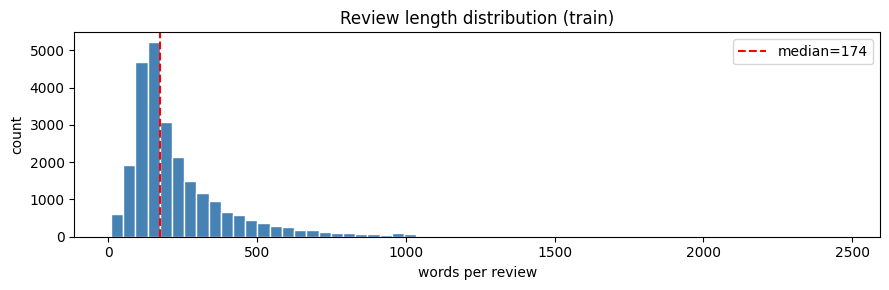

Min: 10 | Max: 2470 | Median: 174 | Mean: 233


In [3]:
# Review length distribution
lengths = [len(r.split()) for r in train['text']]

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(lengths, bins=60, color='steelblue', edgecolor='white')
ax.axvline(np.median(lengths), color='red', linestyle='--', label=f'median={int(np.median(lengths))}')
ax.set_xlabel('words per review')
ax.set_ylabel('count')
ax.set_title('Review length distribution (train)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/eda_length_dist.png', dpi=120)
plt.show()

print(f"Min: {min(lengths)} | Max: {max(lengths)} | Median: {int(np.median(lengths))} | Mean: {int(np.mean(lengths))}")

In [4]:
# Token count after DistilBERT tokenization
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased-finetuned-sst-2-english')
sample = train.select(range(2000))
token_lengths = [len(tokenizer(r, truncation=False)['input_ids']) for r in sample['text']]

pct_over_512 = sum(t > 512 for t in token_lengths) / len(token_lengths) * 100
print(f"Reviews with >512 tokens (truncated): {pct_over_512:.1f}%")
print(f"Median token count: {int(np.median(token_lengths))}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (720 > 512). Running this sequence through the model will result in indexing errors


Reviews with >512 tokens (truncated): 13.2%
Median token count: 232


In [5]:
# Sample reviews
for label_id, label_name in [(0, 'negative'), (1, 'positive')]:
    examples = [r for r, l in zip(train['text'], train['label']) if l == label_id][:2]
    print(f"--- {label_name.upper()} ---")
    for e in examples:
        print(e[:300], '...\n')

--- NEGATIVE ---
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h ...

"I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn't true. I've seen R-rated films with male nudity ...

--- POSITIVE ---
Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more strik ...

Zentropa is the most original movie I've seen in